In [27]:
#import các thư viện cần thiết
import numpy as np
import tensorflow  as tf
import keras 
from keras import layers, models
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from keras.models import load_model
import os


In [ ]:
pathfile = 'train/images/carlong_0002_png.rf.32bb04f1acbcc44a2680d24f38994562.jpg'
img = cv2.imread(pathfile)
print(img.shape[1])

640


Đang load model...

image 1/1 d:\Code\CDIO3\test\images\Tgmt_0902_png.rf.c09ac66c8c8f58eb0b1d15b48f9701f6.jpg: 640x640 1 License-Plate, 96.2ms
Speed: 6.6ms preprocess, 96.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

Tìm thấy 1 biển số:
- Class: License-Plate, Conf: 0.91, Coords: [250, 465, 404, 638]


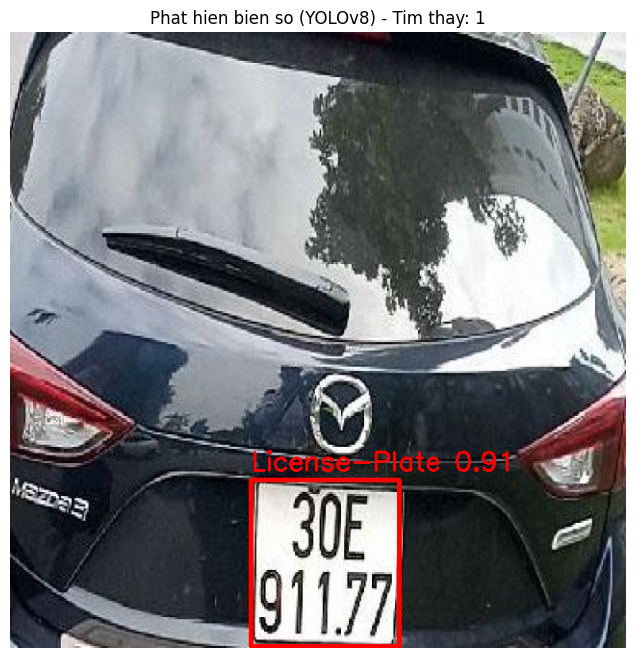

(173, 154, 3)


In [29]:

# 1. CẤU HÌNH ĐƯỜNG DẪN
MODEL_PATH = 'best.pt'
IMAGE_PATH = pathfile

# 2. LOAD MODEL
# Load model YOLOv8 đã train
print("Đang load model...")
model = YOLO(MODEL_PATH)

# 3. DỰ ĐOÁN
results = model(IMAGE_PATH)

# 4. XỬ LÝ KẾT QUẢ VÀ VẼ
# Đọc ảnh gốc để vẽ lên
img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
result = results[0]

# Lấy các bounding boxes
boxes = result.boxes

print(f"\nTìm thấy {len(boxes)} biển số:")

for box in boxes:
    # --- A. Lấy tọa độ ---
    # xyxy: x_min, y_min, x_max, y_max
    # Chuyển sang cpu() và numpy() rồi ép kiểu int để vẽ
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    
    # Lấy độ tin cậy (Confidence)
    conf = float(box.conf[0])
    
    # Lấy tên class
    cls = int(box.cls[0])
    class_name = model.names[cls]

    print(f"- Class: {class_name}, Conf: {conf:.2f}, Coords: [{x1}, {y1}, {x2}, {y2}]")

    # --- B. Vẽ lên ảnh ---
    # Vẽ hình chữ nhật màu Đỏ (Red), độ dày 3
    # Lưu ý: Vì img_rgb đang là RGB nên màu đỏ là (255, 0, 0)
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)

    label = f"{class_name} {conf:.2f}"
    cv2.putText(img_rgb, label, (x1, y1 - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

# 5. HIỂN THỊ BẰNG MATPLOTLIB
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"Phat hien bien so (YOLOv8) - Tim thay: {len(boxes)}")
plt.axis('off')
plt.show()

# --- MẸO: CẮT ẢNH BIỂN SỐ ĐỂ NHẬN DIỆN KÝ TỰ ---
crop_img = img[y1:y2, x1:x2] # Lưu ý thứ tự y trước x sau
print(crop_img.shape)

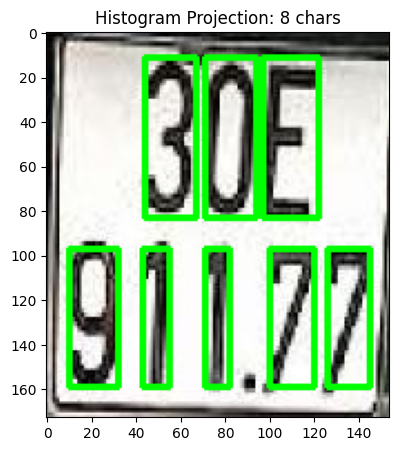

In [30]:

def find_characters_by_projection(warp_img):
    """
    Phương pháp Histogram Projection (ĐÃ SỬA:  loại box khoảng trống)
    """
    if warp_img is None: return []

    # --- BƯỚC 1: TIỀN XỬ LÝ ---
    gray = cv2.cvtColor(warp_img, cv2.COLOR_BGR2GRAY)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    binary = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 19, 5)

    h_img, w_img = binary.shape

    # --- BƯỚC 2: CẮT VIỀN AN TOÀN ---
    roi_x = int(w_img * 0.05)
    roi_y = int(h_img * 0.05)
    roi_w = int(w_img * 0.9)
    roi_h = int(h_img * 0.9)
    
    roi_bin = binary[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
    
    # --- BƯỚC 3: TÁCH DÒNG ---
    hist_y = np.sum(roi_bin, axis=1)
    min_val_y = np.max(hist_y) * 0.1 
    
    lines = []
    in_line = False
    start_y = 0
    
    for y, val in enumerate(hist_y):
        if val > min_val_y and not in_line: 
            in_line = True
            start_y = y
        elif val <= min_val_y and in_line:
            in_line = False
            if (y - start_y) > roi_h * 0.2: 
                lines.append((start_y, y))
                
    if in_line: 
        if (len(hist_y) - start_y) > roi_h * 0.2:
            lines.append((start_y, len(hist_y)))

    # --- BƯỚC 4: TÁCH KÝ TỰ ---
    final_rects = []
    
    for (line_y1, line_y2) in lines:
        line_img = roi_bin[line_y1:line_y2, :]
        line_h = line_y2 - line_y1
        
        hist_x = np. sum(line_img, axis=0)
        
        min_val_x = line_h * 255 * 0.11
        
        chars_ranges = []
        in_char = False
        start_x = 0
        
        for x, val in enumerate(hist_x):
            if val > min_val_x and not in_char:
                in_char = True
                start_x = x
            elif val <= min_val_x and in_char:
                in_char = False
                chars_ranges.append((start_x, x))
                
        if in_char:  
            chars_ranges.append((start_x, len(hist_x)))
        
        # Lọc và chuyển đổi tọa độ
        for (x1, x2) in chars_ranges:
            w_char = x2 - x1
            if w_char < roi_w * 0.02 or w_char > roi_w * 0.3:  
                continue
            
            # Map tọa độ
            real_x = x1 + roi_x
            real_y = line_y1 + roi_y
            real_w = w_char
            real_h = line_h
            
            char_roi = binary[real_y:real_y+real_h, real_x:real_x+real_w]
            
            if char_roi.size == 0: 
                continue
            
            # Đếm số pixel trắng (255)
            white_count = np.sum(char_roi == 255)
            total_pixels = char_roi.size
            
            if white_count / total_pixels < 0.09:
                continue
            
            # Số pixel trắng tuyệt đối phải >= 80 pixel
            if white_count < 80:
                continue
            
            # Fine-tune
            padding_y = int(real_h * 0.05)
            final_rects.append((real_x, real_y + padding_y, real_w, real_h - padding_y*2))

    # --- BƯỚC 5: SẮP XẾP ---
    return sort_rects_direct(final_rects)

def sort_rects_direct(rects):
    """Sắp xếp từ trái qua phải, trên xuống dưới"""
    if len(rects) == 0: return []
    rects = sorted(rects, key=lambda r: r[1]) # Sort theo Y
    mean_h = np.mean([r[3] for r in rects])
    lines = []
    current_line = [rects[0]]
    for i in range(1, len(rects)):
        curr, prev = rects[i], rects[i-1]
        if abs(curr[1] - prev[1]) > mean_h * 0.5: # Khác dòng
            lines.append(sorted(current_line, key=lambda r: r[0]))
            current_line = [curr]
        else:
            current_line.append(curr)
    lines.append(sorted(current_line, key=lambda r: r[0]))
    return [r for line in lines for r in line]

def normalize_char(binary_img, x, y, w, h, size=28, pad=2):
    roi = binary_img[y:y+h, x:x+w]
    if roi.size == 0: return None
    roi_h, roi_w = roi.shape
    # Đảo màu nếu nền trắng chữ đen (check góc)
    if np.mean([roi[0,0], roi[0,-1], roi[-1,0]]) > 127:
        roi = cv2.bitwise_not(roi)
    
    max_dim = size - 2*pad
    scale = max_dim / max(roi_h, roi_w)
    nw, nh = int(roi_w*scale), int(roi_h*scale)
    
    if scale > 1: resized = cv2.resize(roi, (nw, nh), interpolation=cv2.INTER_CUBIC)
    else: resized = cv2.resize(roi, (nw, nh), interpolation=cv2.INTER_AREA)
    
    canvas = np.zeros((size, size), dtype=np.uint8)
    dx, dy = (size-nw)//2, (size-nh)//2
    canvas[dy:dy+nh, dx:dx+nw] = resized
    return canvas

def refine_warp_perspective(yolo_crop):
    """ 
    Args:
        yolo_crop: Ảnh đã crop từ YOLO detection
        
    Returns:
        Ảnh đã được warp hoặc ảnh gốc nếu không tìm thấy contour phù hợp
    """
    if yolo_crop is None or yolo_crop.size == 0:
        return yolo_crop
    
    h_orig, w_orig = yolo_crop.shape[:2]
    min_area_threshold = h_orig * w_orig * 0.3
    
    # Preprocessing - tối ưu hóa cho edge detection
    gray = cv2.cvtColor(yolo_crop, cv2.COLOR_BGR2GRAY)
    
    # Sử dụng bilateral filter thay vì Gaussian để giữ edge tốt hơn
    blur = cv2.bilateralFilter(gray, 9, 75, 75)
    
    # Adaptive threshold hoặc OTSU tùy điều kiện ánh sáng
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Morphological operations để làm sạch noise
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours với hierarchy để loại bỏ contour lồng nhau
    contours, hierarchy = cv2.findContours(
        binary, 
        cv2.RETR_EXTERNAL,  # Chỉ lấy external contours
        cv2.CHAIN_APPROX_SIMPLE  # Nén contour points
    )
    
    if not contours:
        return yolo_crop
    
    # Tìm contour tốt nhất dựa trên nhiều tiêu chí
    valid_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area_threshold:
            continue
            
        peri = cv2.arcLength(cnt, True)
        if peri == 0:
            continue
            
        # Thử nhiều epsilon values để tìm approximation tốt nhất
        for epsilon_factor in [0.02, 0.03, 0.04]:
            approx = cv2.approxPolyDP(cnt, epsilon_factor * peri, True)
            
            if len(approx) == 4:
                # Kiểm tra tính convex
                if not cv2.isContourConvex(approx):
                    continue
                
                # Kiểm tra aspect ratio hợp lý (cho biển số xe: 2:1 đến 4:1)
                rect = cv2.minAreaRect(approx)
                width, height = rect[1]
                if width == 0 or height == 0:
                    continue
                    
                aspect_ratio = max(width, height) / min(width, height)
                if aspect_ratio < 1.5 or aspect_ratio > 5:
                    continue
                
                valid_contours.append((area, approx, cnt))
                break
    
    if not valid_contours:
        return yolo_crop
    
    # Chọn contour có diện tích lớn nhất
    _, approx, _ = max(valid_contours, key=lambda x: x[0])
    
    # Order points một cách robust hơn
    pts = approx.reshape(4, 2).astype("float32")
    rect = order_points(pts)
    
    # Tính toán kích thước output
    (tl, tr, br, bl) = rect
    
    # Sử dụng trung bình của cả hai cạnh thay vì max
    width_top = np.linalg.norm(tr - tl)
    width_bottom = np.linalg.norm(br - bl)
    width = int((width_top + width_bottom) / 2)
    
    height_left = np.linalg.norm(tl - bl)
    height_right = np.linalg.norm(tr - br)
    height = int((height_left + height_right) / 2)
    
    # Kiểm tra kích thước output hợp lý
    if width < 50 or height < 20 or width > w_orig * 2 or height > h_orig * 2:
        return yolo_crop
    
    # Destination points
    dst = np.array([
        [0, 0],
        [width - 1, 0],
        [width - 1, height - 1],
        [0, height - 1]
    ], dtype="float32")
    
    # Perspective transform
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(
        yolo_crop, 
        M, 
        (width, height),
        flags=cv2.INTER_LINEAR,  # Hoặc INTER_CUBIC cho chất lượng cao hơn
        borderMode=cv2.BORDER_REPLICATE
    )
    
    return warped


def order_points(pts):
    """
    Sắp xếp points theo thứ tự: top-left, top-right, bottom-right, bottom-left
    Robust hơn phương pháp cũ
    """
    rect = np.zeros((4, 2), dtype="float32")
    
    # Top-left có tổng nhỏ nhất, bottom-right có tổng lớn nhất
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    
    # Top-right có diff nhỏ nhất, bottom-left có diff lớn nhất
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    
    return rect


def refine_warp_perspective_advanced(yolo_crop, target_aspect_ratio=None):
    """
    Version nâng cao với thêm tùy chọn
    
    Args:
        yolo_crop: Ảnh đã crop
        target_aspect_ratio: Tuple (width_ratio, height_ratio) ví dụ (2, 1) cho biển số
        
    Returns:
        Warped image
    """
    result = refine_warp_perspective(yolo_crop)
    
    # Nếu chỉ định aspect ratio, resize về đúng tỉ lệ
    if target_aspect_ratio and result is not yolo_crop:
        h, w = result.shape[:2]
        target_w = int(h * target_aspect_ratio[0] / target_aspect_ratio[1])
        result = cv2.resize(result, (target_w, h), interpolation=cv2.INTER_CUBIC)
    
    return result

def run_demo(crop_img):
    warped = refine_warp_perspective(crop_img)
    
    # GỌI HÀM MỚI Ở ĐÂY
    rects = find_characters_by_projection(warped)
    
    # Vẽ
    vis = warped.copy()
    for (x,y,w,h) in rects:
        cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 2)
        
    plt.figure(figsize=(10,5))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Histogram Projection: {len(rects)} chars")
    plt.show()
    return warped,rects

warped,rects = run_demo(crop_img)

In [31]:
# import tensorflow as tf
# import os

# # ============================================================
# # BƯỚC 1: LOAD DỮ LIỆU & CHUẨN BỊ
# # ============================================================
# data_dir = "dataset"

# # Kiểm tra thư mục có tồn tại không để tránh lỗi
# if not os.path.exists(data_dir):
#     print(f"LỖI: Không tìm thấy thư mục '{data_dir}'. Vui lòng kiểm tra lại đường dẫn.")
#     exit()

# # Load ảnh, tự động resize về 28x28 và chuyển sang ảnh xám (grayscale)
# print("Đang load dữ liệu...")
# train_ds = keras.utils.image_dataset_from_directory(
#     data_dir,
#     validation_split=0.2, # Dành 20% để kiểm tra
#     subset="training",
#     seed=123,
#     image_size=(28, 28),
#     color_mode='grayscale',
#     batch_size=32
# )

# val_ds = keras.utils.image_dataset_from_directory(
#     data_dir,
#     validation_split=0.2,
#     subset="validation",
#     seed=123,
#     image_size=(28, 28),
#     color_mode='grayscale',
#     batch_size=32
# )

# # Lấy thông tin lớp (nhãn)
# class_names = train_ds.class_names
# num_classes = len(class_names)
# print(f"Số lớp: {num_classes}")
# print(f"Danh sách tên lớp: {class_names}")

# # Chuẩn hóa dữ liệu (chia cho 255 để giá trị pixel về khoảng 0-1)
# # Sử dụng map để áp dụng cho toàn bộ dataset
# normalization_layer = layers.Rescaling(1./255)
# train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
# val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# # Tối ưu hiệu năng load dữ liệu (Caching & Prefetching)
# AUTOTUNE = tf.data.AUTOTUNE
# train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
# val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# # ============================================================
# # BƯỚC 2: ĐỊNH NGHĨA MODEL CNN
# # ============================================================
# print("Đang khởi tạo model...")
# model = keras.Sequential([
#     # Input layer: 28x28, 1 kênh màu (grayscale)
#     layers.Input(shape=(28, 28, 1)),
    
#     # Block 1
#     layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D((2, 2)),
    
#     # Block 2
#     layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D((2, 2)),
    
#     # Block 3
#     layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D((2, 2)),
    
#     # Flatten & Dense
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5), # Giảm overfitting
    
#     # Output layer
#     layers.Dense(num_classes, activation='softmax')
# ])

# # Compile model
# model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# model.summary()

# # ============================================================
# # BƯỚC 3: TRAINING (HUẤN LUYỆN)
# # ============================================================
# print("Bắt đầu training...")

# # Thêm EarlyStopping: Dừng nếu val_loss không giảm sau 10 epochs để tiết kiệm thời gian
# early_stopping = keras.callbacks.EarlyStopping(
#     monitor='val_loss', 
#     patience=10, 
#     restore_best_weights=True
# )

# history = model.fit(
#     train_ds, 
#     validation_data=val_ds, 
#     epochs=150,
#     callbacks=[early_stopping] # Kích hoạt dừng sớm
# )

# # ============================================================
# # BƯỚC 4: VẼ ĐỒ THỊ VÀ LƯU MODEL
# # ============================================================

# def plot_training_history(history):
#     acc = history.history.get('accuracy', [])
#     val_acc = history.history.get('val_accuracy', [])
#     loss = history.history['loss']
#     val_loss = history.history['val_loss']

#     epochs_range = range(len(loss))

#     plt.figure(figsize=(12, 6))

#     # Đồ thị Accuracy
#     if acc:
#         plt.subplot(1, 2, 1)
#         plt.plot(epochs_range, acc, label='Training Accuracy')
#         plt.plot(epochs_range, val_acc, label='Validation Accuracy')
#         plt.legend(loc='lower right')
#         plt.title('Training and Validation Accuracy')

#     # Đồ thị Loss
#     plt.subplot(1, 2, 2)
#     plt.plot(epochs_range, loss, label='Training Loss')
#     plt.plot(epochs_range, val_loss, label='Validation Loss')
#     plt.legend(loc='upper right')
#     plt.title('Training and Validation Loss')

#     plt.show()

# plot_training_history(history)

# # Lưu model
# save_path = "model_cnn_v1.keras"
# model.save(save_path)
# print(f"Đã lưu model tại: {save_path}")

Đã load model thành công!

--- KẾT QUẢ DỰ ĐOÁN ---
Ký tự #1: 3 (Tin cậy: 100.0%)
  - Ký tự 1: '3' (100.0%)
Ký tự #2: 0 (Tin cậy: 100.0%)
  - Ký tự 2: '0' (100.0%)
Ký tự #3: E (Tin cậy: 100.0%)
  - Ký tự 3: 'E' (100.0%)
Ký tự #4: 9 (Tin cậy: 100.0%)
  - Ký tự 4: '9' (100.0%)
Ký tự #5: 1 (Tin cậy: 100.0%)
  - Ký tự 5: '1' (100.0%)
Ký tự #6: 1 (Tin cậy: 99.4%)
  - Ký tự 6: '1' (99.4%)
Ký tự #7: 0 (Tin cậy: 98.9%)
  - Ký tự 7: '0' (98.9%)
Ký tự #8: 7 (Tin cậy: 100.0%)
  - Ký tự 8: '7' (100.0%)
BIỂN SỐ HOÀN CHỈNH: 30E91107


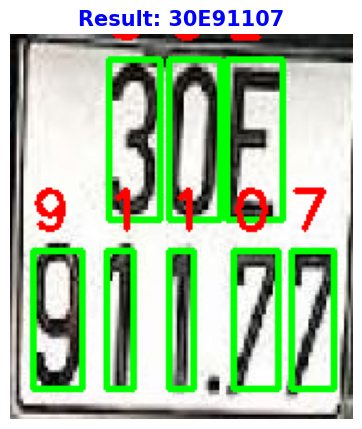

In [32]:


# ==========================================
# 1. CẤU HÌNH & LOAD MODEL
# ==========================================

MODEL_PATH = "model_cnn_v2.keras" 
# MODEL_PATH = "model_cnn_v1.keras"
# Load Model
try:
    model = keras.models.load_model(MODEL_PATH)
    print("Đã load model thành công!")
except:
    print(f"Không tìm thấy file '{MODEL_PATH}'. Hãy train và lưu model trước.")
    # Tạo model giả để code không lỗi
    model = keras.Sequential([keras.layers.Dense(36, activation='softmax')]) 

# DANH SÁCH TÊN LỚP (CLASS NAMES)
# image_dataset_from_directory mặc định sắp xếp theo Alphanumeric (0-9, A-Z)
CLASS_NAMES = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H','K', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U',
    'V', 'X', 'Y', 'Z'
]


def predict_single_character(char_img_28x28):
    """
    Input: Ảnh ký tự 28x28 (numpy array), nền đen chữ trắng (giống lúc train)
    Output: Ký tự dự đoán (String) và độ tin cậy
    """
    # 1. Chuẩn hóa về [0, 1] (Vì lúc train bạn đã dùng Rescaling 1./255)
    img_norm = char_img_28x28.astype("float32") / 255.0

    # 2. Reshape để đúng định dạng đầu vào của CNN: (Batch_Size, Height, Width, Channels)
    # Ảnh gốc: (28, 28) -> Thêm kênh màu: (28, 28, 1) -> Thêm Batch: (1, 28, 28, 1)
    img_input = np.expand_dims(img_norm, axis=-1)
    img_input = np.expand_dims(img_input, axis=0)

    # 3. Dự đoán
    # verbose=0 để tắt thanh tiến trình chạy mỗi lần predict
    predictions = model.predict(img_input, verbose=0)
    
    # 4. Lấy kết quả
    score =  predictions[0]
    predicted_index = np.argmax(score) # Lấy vị trí có xác suất cao nhất
    predicted_char = CLASS_NAMES[predicted_index]
    confidence = np.max(score) * 100

    return predicted_char, confidence


def recognize_plate(yolo_crop, rects):
    """
    Input: 
      - yolo_crop: Ảnh biển số từ bước Warp
      - rects: Danh sách tọa độ [x,y,w,h] từ bước find_characters
    Output:
      - license_plate_str: Chuỗi biển số (VD: 51A12345)
    """
    # Sắp xếp rects từ trái sang phải, trên xuống dưới (đã có hàm sort ở bước trước)
    # rects = sort_rects_direct(rects) # Giả sử bạn đã gọi hàm sort trước khi truyền vào đây
    if len(yolo_crop.shape) == 2:
        vis_img = cv2.cvtColor(yolo_crop, cv2.COLOR_GRAY2BGR)
    else:
        vis_img = yolo_crop.copy()
    # Chuẩn bị ảnh binary để cắt (như cũ)
    gray = cv2.cvtColor(yolo_crop, cv2.COLOR_BGR2GRAY)
    _, bin_plate = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.sum(bin_plate == 255) > np.sum(bin_plate == 0):
        bin_plate = cv2.bitwise_not(bin_plate)

    full_plate_number = ""
    print("\n--- KẾT QUẢ DỰ ĐOÁN ---")

    for i, (x, y, w, h) in enumerate(rects):
        # 1. Cắt và chuẩn hóa ảnh ký tự (về 28x28)
        # (Hàm process_char_standardized bạn đã có ở bước trước)
        char_img = normalize_char(bin_plate, x, y, w, h)
        
        if char_img is not None:
            # 2. Đưa vào CNN dự đoán
            char, conf = predict_single_character(char_img)
            
            # 3. Ghép vào chuỗi kết quả
            full_plate_number += char
            print(f"Ký tự #{i+1}: {char} (Tin cậy: {conf:.1f}%)")
        cv2.rectangle(vis_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # 2. Viết chữ dự đoán lên trên đầu khung (Màu Đỏ)
        # Font chữ, kích thước, độ dày
        cv2.putText(vis_img, char, (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        
        print(f"  - Ký tự {i+1}: '{char}' ({conf:.1f}%)")
    print(f"BIỂN SỐ HOÀN CHỈNH: {full_plate_number}")
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Result: {full_plate_number}", fontsize=15, color='blue', fontweight='bold')
    plt.axis("off")
    plt.show()
    return full_plate_number
license_text = recognize_plate(warped, rects)